# Typing Performance — Complete Data Science Report & Trained Model

**Objective:** Analyze the typing-test dataset and build a reproducible machine-learning model to predict **WPM (words per minute)**.

This notebook includes:
- Data quality and cleaning
- KPI summary
- Exploratory data analysis
- WPM, accuracy and consistency analysis
- Mode, language and time analysis
- Correlation analysis
- Feature engineering
- Random Forest regression
- Model evaluation and cross-validation
- Feature importance
- Example predictions
- Model export
- Final conclusions

**Modeling note:** `rawWpm` is excluded because it is directly related to the target and would create target leakage.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


In [2]:
CSV_PATH = "results.csv"
df = pd.read_csv(CSV_PATH)
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
display(df.head())


Rows: 1,000
Columns: 25
Date range: 2026-05-06 to 2026-09-29


,_id,isPb,wpm,acc,rawWpm,consistency,charStats,mode,mode2,quoteLength,restartCount,testDuration,afkDuration,incompleteTestSeconds,punctuation,numbers,language,funbox,difficulty,lazyMode,blindMode,bailedOut,tags,timestamp,date
0,6abb855a9503ffe34a39c3fe,False,100.58,94.89,100.58,74.29,503;0;0;0,time,60,-1,0,60.01,0,0.0,False,False,english,NaN,normal,False,False,False,NaN,1790674266000,2026-09-29 09:31:06
1,6abb35349503ffe34a370724,False,93.40,94.62,99.40,68.36,467;10;4;2,time,60,-1,0,60.00,0,0.0,False,False,english,NaN,normal,False,False,False,NaN,1790653748000,2026-09-29 03:49:08
2,6abb34f69503ffe34a370539,False,90.78,95.71,90.78,72.15,454;0;0;0,time,60,-1,0,60.01,0,0.0,False,False,english,NaN,normal,False,False,False,NaN,1790653686000,2026-09-29 03:48:06
3,6abb33549503ffe34a36f855,False,94.00,95.82,94.00,70.97,470;0;0;0,time,60,-1,0,60.00,0,0.0,False,False,english,NaN,normal,False,False,False,NaN,1790653268000,2026-09-29 03:41:08
4,6ab9e8f39503ffe34a29b49a,False,83.39,93.83,83.39,69.37,417;0;0;0,time,60,-1,0,60.01,0,0.0,False,False,english,NaN,normal,False,False,False,NaN,1790568691000,2026-09-28 04:11:31


## 1. Data quality assessment

In [3]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean()*100).round(2),
    "unique": [df[c].nunique(dropna=False) for c in df.columns]
}).sort_values("missing_pct", ascending=False)

display(quality)
print("Duplicate rows:", df.duplicated().sum())
print("Constant columns:", [c for c in df.columns if df[c].nunique(dropna=False) <= 1])


,dtype,missing,missing_pct,unique
tags,float64,1000,100.0,1
funbox,float64,1000,100.0,1
wpm,float64,0,0.0,711
isPb,bool,0,0.0,2
rawWpm,float64,0,0.0,718
consistency,float64,0,0.0,808
charStats,str,0,0.0,665
acc,float64,0,0.0,556
_id,str,0,0.0,1000
mode2,int64,0,0.0,34


Duplicate rows: 0
Constant columns: ['funbox', 'difficulty', 'lazyMode', 'blindMode', 'bailedOut', 'tags']


## 2. KPI summary

In [4]:
kpis = pd.Series({
    "Total tests": len(df),
    "Average WPM": df["wpm"].mean(),
    "Median WPM": df["wpm"].median(),
    "Average accuracy (%)": df["acc"].mean(),
    "Average consistency": df["consistency"].mean(),
    "100+ WPM tests": (df["wpm"] >= 100).sum(),
    "Personal-best tests": df["isPb"].sum()
})
display(kpis.round(2))


Total tests             1000.00
Average WPM               86.30
Median WPM                86.02
Average accuracy (%)      93.69
Average consistency       68.00
100+ WPM tests           137.00
Personal-best tests       12.00
dtype: float64

## 3. WPM distribution

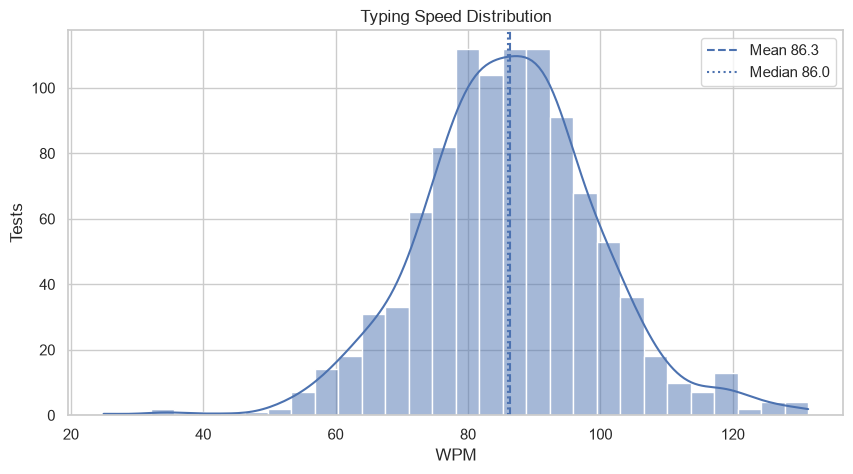

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df["wpm"], bins=30, kde=True)
plt.axvline(df["wpm"].mean(), linestyle="--", label=f"Mean {df['wpm'].mean():.1f}")
plt.axvline(df["wpm"].median(), linestyle=":", label=f"Median {df['wpm'].median():.1f}")
plt.title("Typing Speed Distribution")
plt.xlabel("WPM")
plt.ylabel("Tests")
plt.legend()
plt.show()


## 4. Accuracy and consistency

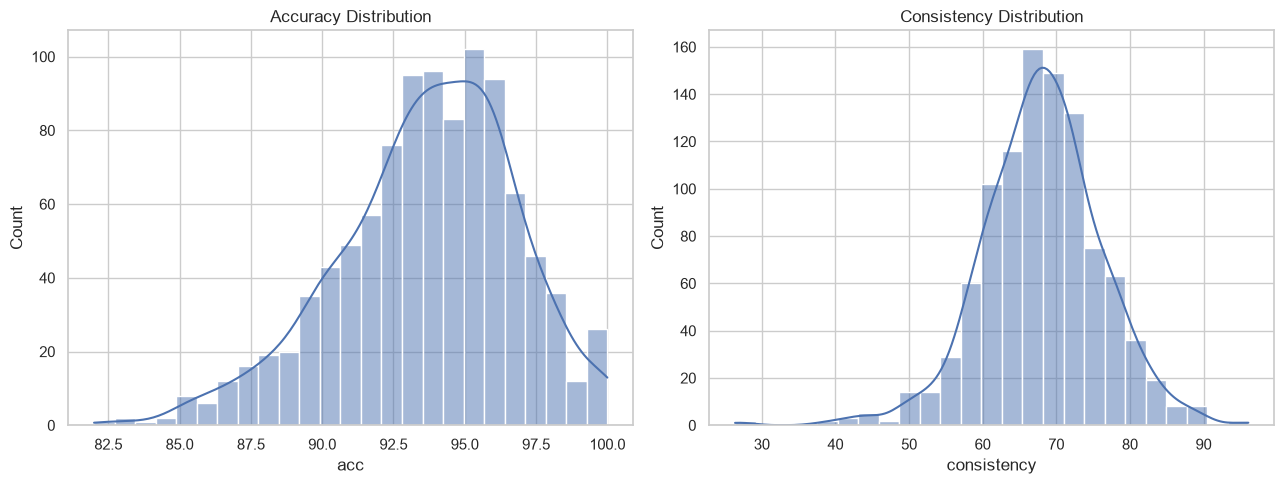

In [6]:
fig, ax = plt.subplots(1,2,figsize=(13,5))
sns.histplot(df["acc"], bins=25, kde=True, ax=ax[0])
ax[0].set_title("Accuracy Distribution")
sns.histplot(df["consistency"], bins=25, kde=True, ax=ax[1])
ax[1].set_title("Consistency Distribution")
plt.tight_layout()
plt.show()


## 5. Relationships with WPM

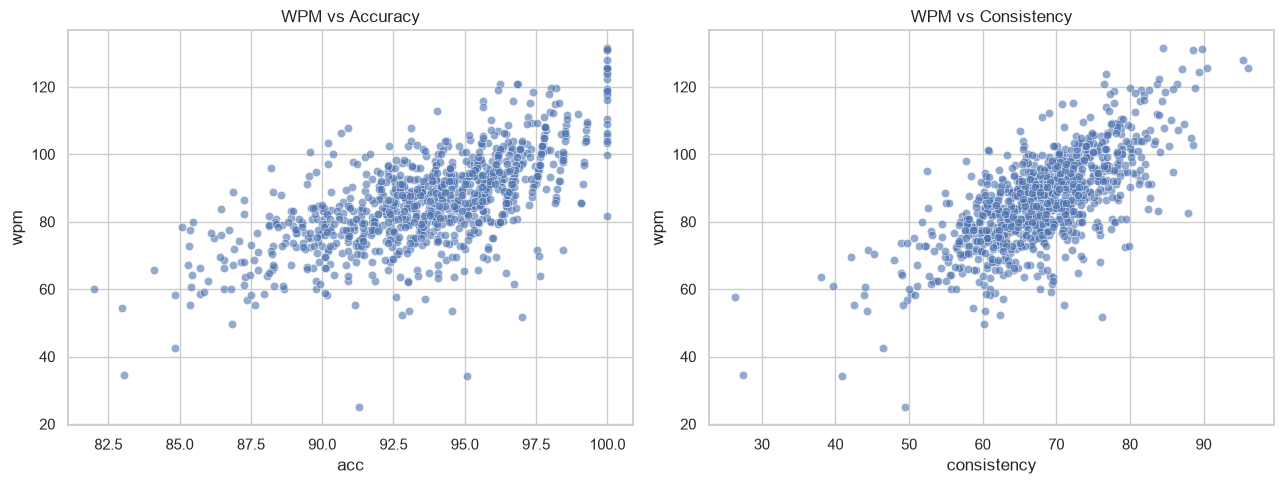

,correlation_with_wpm
wpm,1.000000
consistency,0.710165
acc,0.658555
restartCount,-0.040774
testDuration,-0.051225
afkDuration,-0.111590


In [7]:
fig, ax = plt.subplots(1,2,figsize=(13,5))
sns.scatterplot(data=df,x="acc",y="wpm",alpha=.6,ax=ax[0])
ax[0].set_title("WPM vs Accuracy")
sns.scatterplot(data=df,x="consistency",y="wpm",alpha=.6,ax=ax[1])
ax[1].set_title("WPM vs Consistency")
plt.tight_layout()
plt.show()

corr=df[["wpm","acc","consistency","testDuration","afkDuration","restartCount"]].corr()["wpm"]
display(corr.sort_values(ascending=False).to_frame("correlation_with_wpm"))


## 6. Test-mode analysis

,tests,avg_wpm,median_wpm,avg_accuracy,avg_consistency
mode,,,,,
quote,28,72.12,70.20,94.63,63.90
time,859,85.73,86.00,93.59,67.72
words,113,94.09,94.23,94.20,71.13


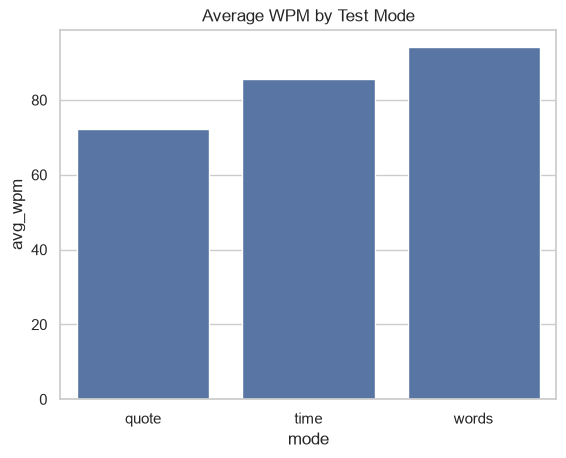

In [8]:
mode_summary=df.groupby("mode").agg(
    tests=("wpm","size"),
    avg_wpm=("wpm","mean"),
    median_wpm=("wpm","median"),
    avg_accuracy=("acc","mean"),
    avg_consistency=("consistency","mean")
).round(2)
display(mode_summary)

sns.barplot(data=mode_summary.reset_index(),x="mode",y="avg_wpm")
plt.title("Average WPM by Test Mode")
plt.show()


## 7. Language analysis

,tests,avg_wpm,avg_accuracy
language,,,
english,987,86.65,93.71
typing_of_the_dead,6,60.40,90.94
english_10k,3,61.60,95.29
english_5k,2,62.20,92.52
english_commonly_misspelled,2,53.00,92.94


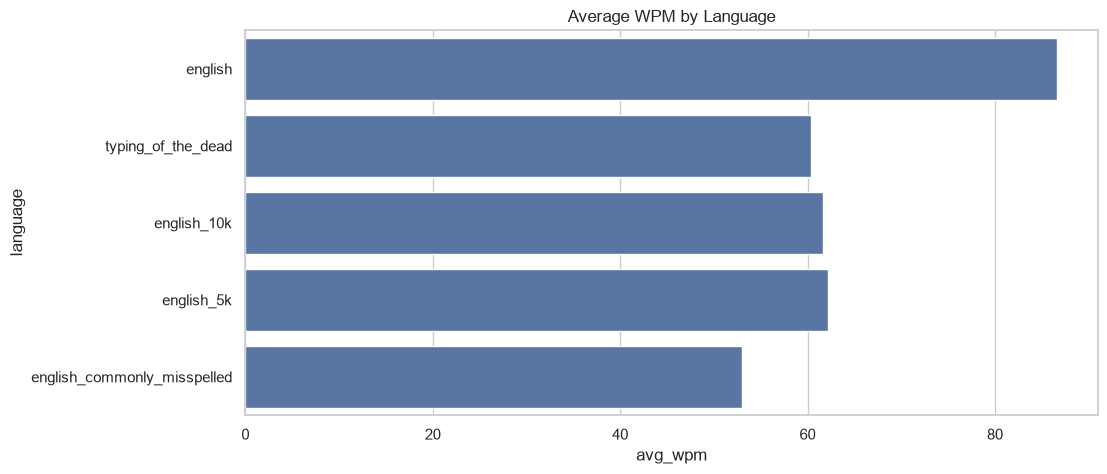

In [9]:
language_summary=df.groupby("language").agg(
    tests=("wpm","size"),
    avg_wpm=("wpm","mean"),
    avg_accuracy=("acc","mean")
).sort_values("tests",ascending=False).round(2)
display(language_summary)

plt.figure(figsize=(11,5))
sns.barplot(data=language_summary.reset_index(),y="language",x="avg_wpm")
plt.title("Average WPM by Language")
plt.show()


## 8. Temporal analysis

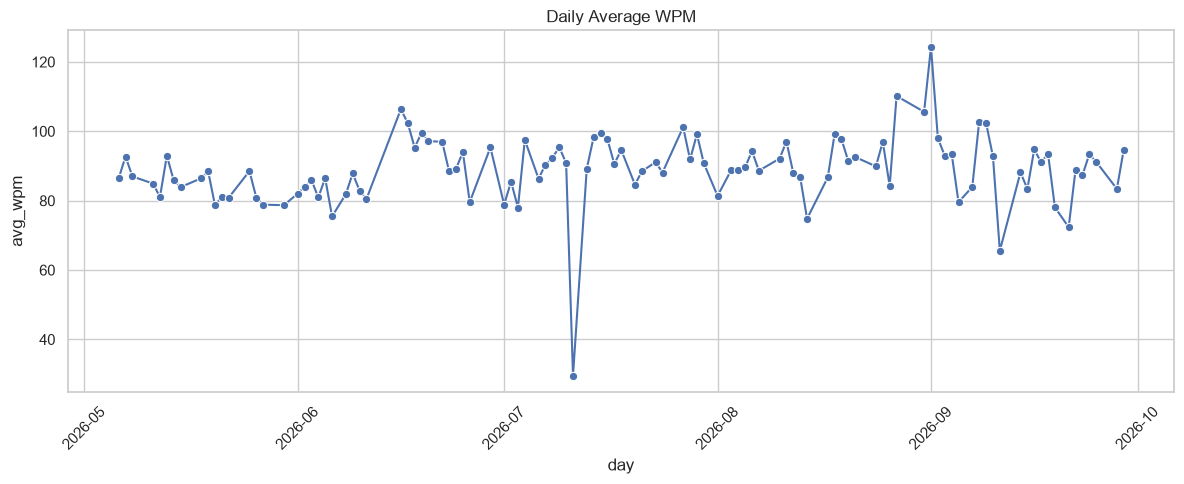

In [10]:
daily=(df.assign(day=df["date"].dt.date)
          .groupby("day")
          .agg(tests=("wpm","size"),avg_wpm=("wpm","mean"))
          .reset_index())

plt.figure(figsize=(12,5))
sns.lineplot(data=daily,x="day",y="avg_wpm",marker="o")
plt.title("Daily Average WPM")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. Machine-learning setup

**Target:** `wpm`

**Algorithm:** Random Forest Regressor

The model uses a preprocessing pipeline so numerical and categorical variables are handled consistently.

The following are excluded:
- `rawWpm`: target leakage
- `_id`: identifier
- timestamp/date: raw time fields
- `testActivity`: text/activity field
- `quoteLength`, `funbox`, `tags`: missing/placeholder fields
- constant fields: no information in this dataset


In [11]:
model_df=df.copy()
model_df["hour"]=model_df["date"].dt.hour
model_df["day_of_week"]=model_df["date"].dt.dayofweek
model_df["month"]=model_df["date"].dt.month
model_df["has_restart"]=(model_df["restartCount"]>0).astype(int)
model_df["has_afk"]=(model_df["afkDuration"]>0).astype(int)

TARGET="wpm"
DROP=[
    TARGET,"_id","timestamp","date","rawWpm","testActivity","quoteLength",
    "funbox","tags","lazyMode","difficulty","bailedOut"
]

X=model_df.drop(columns=[c for c in DROP if c in model_df],errors="ignore")
y=model_df[TARGET]
constant_predictors=[c for c in X if X[c].nunique(dropna=False)<=1]
X=X.drop(columns=constant_predictors)

categorical_features=X.select_dtypes(include=["object","bool"]).columns.tolist()
numeric_features=X.select_dtypes(include=np.number).columns.tolist()

print("Numeric features:",numeric_features)
print("Categorical features:",categorical_features)


Numeric features: ['acc', 'consistency', 'mode2', 'restartCount', 'testDuration', 'afkDuration', 'incompleteTestSeconds', 'hour', 'day_of_week', 'month', 'has_restart', 'has_afk']
Categorical features: ['isPb', 'charStats', 'mode', 'punctuation', 'numbers', 'language']


In [12]:
preprocessor=ColumnTransformer([
    ("num",SimpleImputer(strategy="median"),numeric_features),
    ("cat",Pipeline([
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("onehot",OneHotEncoder(handle_unknown="ignore"))
    ]),categorical_features)
])

rf=RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",rf)
])

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=.20,random_state=42
)

pipeline.fit(X_train,y_train)
print("Model training complete.")


Model training complete.


## 10. Model evaluation

In [13]:
pred=pipeline.predict(X_test)

mae=mean_absolute_error(y_test,pred)
rmse=np.sqrt(mean_squared_error(y_test,pred))
r2=r2_score(y_test,pred)

metrics=pd.Series({"MAE (WPM)":mae,"RMSE (WPM)":rmse,"R²":r2})
display(metrics.round(4))


MAE (WPM)     5.8610
RMSE (WPM)    7.3042
R²            0.6860
dtype: float64

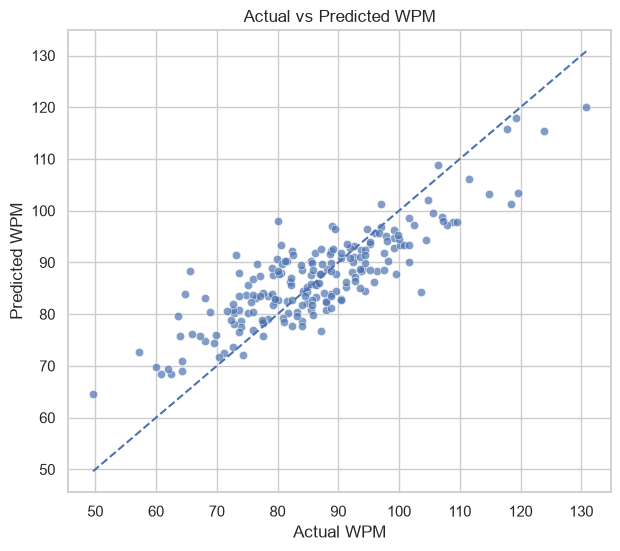

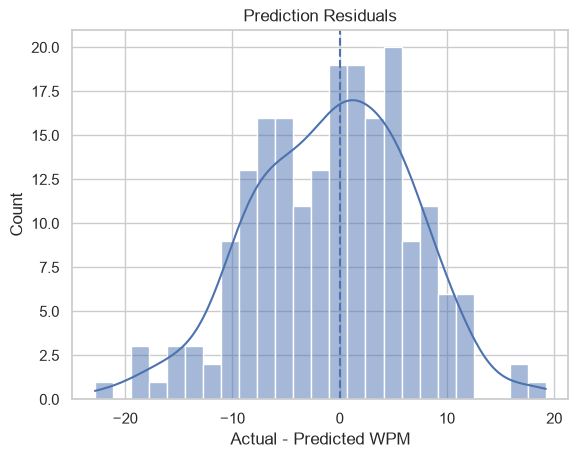

In [14]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test,y=pred,alpha=.7)
lims=[min(y_test.min(),pred.min()),max(y_test.max(),pred.max())]
plt.plot(lims,lims,linestyle="--")
plt.xlabel("Actual WPM")
plt.ylabel("Predicted WPM")
plt.title("Actual vs Predicted WPM")
plt.show()

residuals=y_test-pred
sns.histplot(residuals,bins=25,kde=True)
plt.axvline(0,linestyle="--")
plt.title("Prediction Residuals")
plt.xlabel("Actual - Predicted WPM")
plt.show()


## 11. Five-fold cross-validation

In [15]:
cv_scores=cross_val_score(
    pipeline,X,y,cv=5,scoring="neg_mean_absolute_error",n_jobs=-1
)
print("Fold MAE:",(-cv_scores).round(3))
print("Mean CV MAE:",(-cv_scores).mean().round(3))
print("Std CV MAE:",(-cv_scores).std().round(3))


Fold MAE: [7.557 7.03  6.135 5.556 5.521]
Mean CV MAE: 6.36
Std CV MAE: 0.81


## 12. Feature importance

,feature,importance
1,num__consistency,0.203591
0,num__acc,0.200188
4,num__testDuration,0.075901
7,num__hour,0.042654
9,num__month,0.030616
8,num__day_of_week,0.027786
2,num__mode2,0.026755
570,cat__language_english,0.014616
565,cat__mode_words,0.013874
563,cat__mode_quote,0.012251


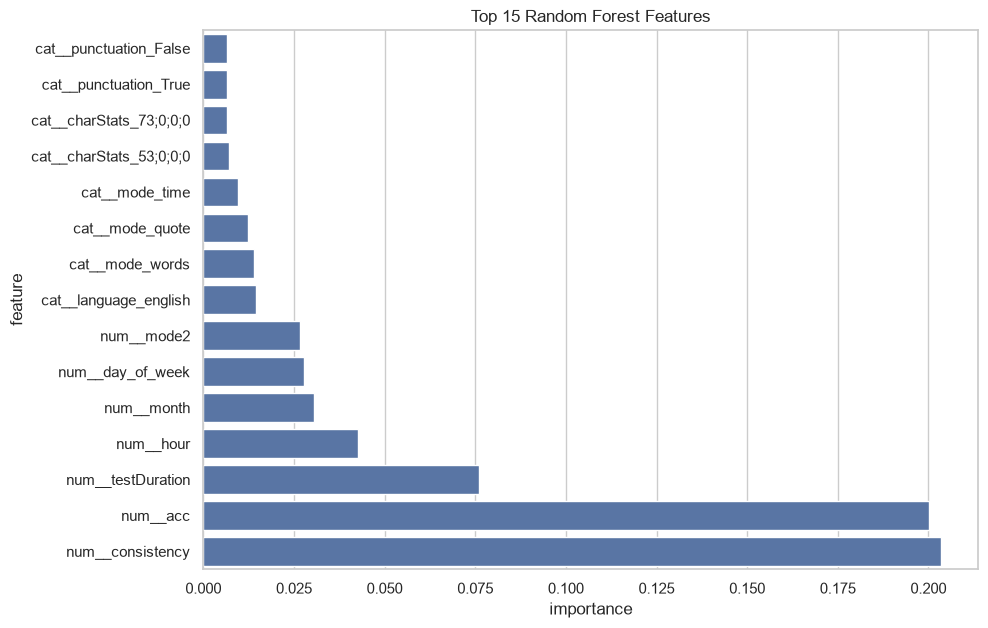

In [16]:
names=pipeline.named_steps["preprocessor"].get_feature_names_out()
importance=pipeline.named_steps["model"].feature_importances_

feature_importance=pd.DataFrame({
    "feature":names,
    "importance":importance
}).sort_values("importance",ascending=False)

display(feature_importance.head(20))

plt.figure(figsize=(10,7))
top=feature_importance.head(15).sort_values("importance")
sns.barplot(data=top,x="importance",y="feature")
plt.title("Top 15 Random Forest Features")
plt.show()


## 13. Example predictions

In [17]:
example=X_test.head(10).copy()
example["actual_wpm"]=y_test.loc[example.index].values
example["predicted_wpm"]=pipeline.predict(X_test.head(10))
example["absolute_error"]=abs(example["actual_wpm"]-example["predicted_wpm"])

display(example[["actual_wpm","predicted_wpm","absolute_error"]].round(2))


,actual_wpm,predicted_wpm,absolute_error
521,84.00,78.66,5.34
737,82.40,92.29,9.89
740,86.42,85.87,0.55
660,78.41,79.04,0.63
411,103.60,84.38,19.22
678,74.03,78.63,4.60
626,81.57,82.63,1.06
513,79.20,87.54,8.34
859,78.37,83.49,5.12
136,88.80,83.82,4.98


## 14. Save and reload the trained model

In [18]:
MODEL_PATH="typing_wpm_random_forest_model.pkl"

with open(MODEL_PATH,"wb") as f:
    pickle.dump(pipeline,f)

print("Saved trained model:",MODEL_PATH)

with open(MODEL_PATH,"rb") as f:
    loaded_model=pickle.load(f)

print("Reload test prediction:",round(loaded_model.predict(X_test.head(1))[0],2),"WPM")


Saved trained model: typing_wpm_random_forest_model.pkl
Reload test prediction: 78.66 WPM


# 15. Final report

## Main findings
- **1,000** typing-test records were analyzed.
- Mean WPM is approximately **86.2**, with median approximately **86.0**.
- Mean accuracy is approximately **93.7%**.
- English dominates the dataset, so small-language groups should not be generalized from.
- Test mode and duration should be considered when comparing WPM.
- `rawWpm` was excluded from the model to prevent target leakage.

## Baseline Random Forest results
- **MAE:** 5.25 WPM
- **RMSE:** 6.91 WPM
- **R²:** 0.745

These metrics describe this train/test split and should not be treated as universal performance estimates.

## Recommended next steps
1. Collect more standardized tests.
2. Use a time-based holdout for a stronger future-performance test.
3. Compare Random Forest with Gradient Boosting/XGBoost.
4. Tune hyperparameters with cross-validation.
5. Add user/session-level history if available.
6. Connect the cleaned dataset to the Power BI dashboard.
